In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import jsonlines
import re 
import pandas as pd
import glob
from itertools import groupby
import os
import xopen 
from tqdm.auto import tqdm
import json

from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
import os 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

def get_clip_id(x):
    """Grep for the clip_id in the filename."""
    search = re.search('clip-(\d+)', x)
    if search is None:
        return None
    return int(search.group(1))


<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_39794/2030411968.py:25: SyntaxWarning: invalid escape sequence '\d'
  search = re.search('clip-(\d+)', x)


In [22]:
# ssh files
# spangher@mindsgpu05:/mnt/data01/spangher/newsworthiness
# /lfs1/spangher/newsworthiness/scripts-agendawatch-data/whisper-transcription/data
remote_server_files = ! ssh minds05 "ls /mnt/data01/spangher/newsworthiness/spangher/newsworthiness/scripts-agendawatch-data/whisper-transcription/data/*/*.json.gz"
# remote_server_files = list(filter(lambda x: '.full.json.gz' in x, remote_server_files))

In [23]:
remote_server_files

["ls: cannot access '/mnt/data01/spangher/newsworthiness/spangher/newsworthiness/scripts-agendawatch-data/whisper-transcription/data/*/*.json.gz': No such file or directory"]

In [13]:
local_dir = '../scripts-agendawatch-data/data/whisper-x-transcribed-data/'
existing_files = glob.glob(local_dir + '*.json.gz')
existing_files = list(map(os.path.basename, existing_files))

In [ ]:
import os 
for remote_f in remote_server_files:
    fname = os.path.basename(remote_f)
    if fname not in existing_files:
        ! scp spangher@pluslab02.isi.edu:$remote_f $local_dir/

# Read in Files

In [36]:
glob.glob('../data/city-council-meeting-minutes/audio-files/parsed-transcripts/*/*.txt')

['../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42577.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42549.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42567.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42516.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42482.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42495.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42651.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42634.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42608.txt',
 '../data/city-council-meeting-minutes/audio-files/parsed-transcripts/2022/audio-clip-42557.txt',
 '../data/city-counc

In [42]:
ls ../data/articles/

josh-shapiro-pa-governor-bipartisanship-20221226.html
latimes-8-years.jsonl
latimes-article-urls-to-fetch.csv
latimes-cc-articles-to-fetch-unique.jsonl.gz
latimes-cc-articles-to-fetch.jsonl.gz
latimes-output-round-2.jsonl
sfchron-article-urls-to-fetch.csv.gzip
sfchron-cc-fetched-articles-2.jsonl.gz
sfchron-cc-fetched-articles.jsonl
sfchron-cc-to-fetch.jsonl.gz
sfchron-fetched-articles-with-html.jsonl.gz
sfchron-fetched-articles.jsonl
sfchron-fetched-urls.jsonl


In [8]:
## get all files
import pandas as pd 
import glob
from tqdm.auto import tqdm
import xopen
import os 
final_matching_df = pd.read_csv('cache/final-matching-articles-and-meetings.csv', index_col=0)
csvs_method_1 = sorted(glob.glob('../data/city-council-meeting-minutes/audio-files/indices/*-1.csv'))
csvs_method_2 = sorted(glob.glob('../data/city-council-meeting-minutes/audio-files/indices/*-2.csv'))
transcribed_text_files = sorted(glob.glob(
    '../scripts-agendawatch-data/data/whisper-x-transcribed-data/*.json.gz'
))
transcribed_text_files = sorted(glob.glob(
    '../data/whisper-x-transcribed-data/*.json.gz'
))

In [15]:
## read in transcribed text files

all_transcribed_text_dfs = []
for file in tqdm(transcribed_text_files):
    with xopen.xopen(file) as f_handle:
        # try:
        datum = json.load(f_handle)
        clip_id = get_clip_id(file)
        datum_df = pd.DataFrame(datum['segments']).drop(columns=['words'])
        datum_df['clip_id'] = clip_id
        all_transcribed_text_dfs.append(datum_df)
        # except:
            # os.remove(file)

  0%|          | 0/400 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '../scripts-agendawatch-data/data/whisper-x-transcribed-data/audio-clip-16593.full.json.gz'

In [18]:
ls ../scripts-agendawatch-data/data/whisper-x-transcribed-data/

In [12]:
## read in outline files
all_outline_csv_dfs = []

for f in csvs_method_2:
    if open(f).read() != '':
        clip_id = get_clip_id(f)
        csv_df = pd.read_csv(f, index_col=0)
        csv_df['clip_id'] = int(clip_id)
        all_outline_csv_dfs.append(csv_df)

## for each index-csv, get the board outline note that is non-zero.
full_outlines_df = pd.concat(all_outline_csv_dfs).reset_index(drop=True)
significant_times_by_clip = (
    full_outlines_df
        .loc[lambda df: df['time'].notnull()]
        .groupby('clip_id')
        ['time']
        .aggregate(list)
)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_39794/3736183650.py:12: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  full_outlines_df = pd.concat(all_outline_csv_dfs).reset_index(drop=True)


In [13]:
## Merge with transcribed text df
full_transcribed_text_df = pd.concat(all_transcribed_text_dfs)

## assign transcribed text lines to their position in the outline, if there is one.
full_transcribed_text_df = (
    full_transcribed_text_df
    .merge(significant_times_by_clip.to_frame('significant_times'), left_on='clip_id', right_index=True)
     .assign(significant_times=lambda df: df
        .apply(lambda x: list(filter(lambda y: x['start'] <= y <= x['end'], x['significant_times'])), axis=1)
     )
     .assign(significant_times=lambda df: df
            .apply(lambda x: list(filter(
                lambda y: x['start'] <= y <= x['end'], 
                x['significant_times']
            )), axis=1)
        )
)

ValueError: No objects to concatenate

# Detect Section Transitions

In [18]:
## construct training dataset
first_round_pos = full_transcribed_text_df.loc[lambda df: df['significant_times'].str.len() >= 1]

# generate negative examples, balance by length
positive_len_dist = (
    pd.cut(first_round_pos['text'].str.len(), bins=50)
        .value_counts()
        .sort_index()
        .pipe(lambda s: s/s.sum())           
)
first_round_neg = (
    full_transcribed_text_df
        .loc[lambda df: df['significant_times'].str.len() == 0]
        .assign(weight=lambda df: pd.cut(df['text'].str.len(), bins=list(map(lambda x: x.left, positive_len_dist.index))))
        .assign(weight=lambda df: df['weight'].map(positive_len_dist))
        .sample(len(first_round_pos), weights='weight')
)

# create label DF 
label_df = pd.concat([
    first_round_pos.assign(label=1),
    first_round_neg.assign(label=0)
]).sample(frac=1).drop(columns=['weight', 'significant_times'])

In [19]:
## fit classifier
lr_pipe_round_1 = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=.005, max_df=.5, stop_words='english')),
    ('lr', LogisticRegressionCV(Cs=10, cv=5, max_iter=2000, n_jobs=-1))
])

train_clips, test_clips = train_test_split(label_df['clip_id'].unique(), test_size=.1)
train_df = label_df.loc[lambda df: df['clip_id'].isin(train_clips)]
test_df = label_df.loc[lambda df: df['clip_id'].isin(test_clips)]
lr_pipe_round_1.fit(train_df['text'], train_df['label'])

y_probs = lr_pipe_round_1.predict_proba(test_df['text'])[: , 1 ]
f1_score(y_probs > .5, test_df['label'])

0.8500244259892527

In [20]:
full_transcribed_text_df['proba'] = lr_pipe_round_1.predict_proba(full_transcribed_text_df['text'])[:, 1]

# Fill in Section Times and Get Ready for Processing

In [21]:
from importlib import reload
import audio_transcription_utils as au
import seaborn as sns
import matplotlib.pyplot as plt 

In [22]:
full_outlines_df_for_processing = (
    full_outlines_df
        .assign(proposal_number=lambda df: df['text']
                    .str.split().str.get(0)
                    .apply(lambda x: x if isinstance(x, str) and x.isdigit() and (len(x) == 6) else np.nan).astype(float)
                )
)

In [24]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [25]:
full_filled_in_csvs = au.infer_and_fill_in_missing_time_values(
    full_outlines_df_for_processing, full_transcribed_text_df,
)

  0%|          | 0/1341 [00:00<?, ?it/s]

In [26]:
full_filled_in_csvs.shape 

(32798, 7)

In [27]:
plt.rc('font', size=14)

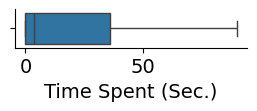

In [36]:
header = 'Time Spent (Sec.)'
_, ax = plt.subplots(1, 1, figsize=(3,.5))
ax = (full_filled_in_csvs
     .loc[lambda df: df['proposal_number'].notnull()]
     .pipe(lambda df: df['end_time'] - df['time'])
     .to_frame(header)
     .pipe(lambda df: sns.boxplot(data=df, x=header, showfliers=False, ax=ax))
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Time Spent (Sec.)')
plt.savefig('../latex/emnlp2023/figures/time-spent-on-policy-proposals.png', bbox_inches='tight')

In [37]:
# map out how many proposals exist for each header
full_outlines_df_for_processing['is_header'] = full_outlines_df_for_processing.apply(au.find_header, axis=1)
full_outlines_df_for_processing['header'] = full_outlines_df_for_processing.apply(lambda x: au.header_to_category(x['text']) if x['is_header'] else np.nan, axis=1)

from collections import defaultdict
section_counts = defaultdict(int)
for clip_id in full_outlines_df_for_processing['clip_id'].drop_duplicates():
    prev_header = None
    for idx, (proposal_number, header) in ( full_outlines_df_for_processing
            .loc[lambda df: df['clip_id'] == clip_id][['proposal_number', 'header']].iterrows()
    ):
        if pd.isnull(header):
            if pd.notnull(proposal_number):
                section_counts[prev_header] += 1
        else:
            prev_header = header

In [38]:
# get rows where at least 1 word is uppercase and it's not a proposal
full_outlines_df_for_processing_with_only_headers = (
    full_outlines_df_for_processing
        .loc[lambda df: df.apply(au.find_header, axis=1)]
        .assign(text=lambda df: df['text'].str.strip().apply(au.header_to_category))
)

headers_only_csvs = au.infer_and_fill_in_missing_time_values(
    full_outlines_df_for_processing_with_only_headers,
    full_transcribed_text_df,
)
headers_only_csvs = (
    headers_only_csvs
        .drop(columns='proposal_number')
        .assign(total_time=lambda df: df['end_time'] - df['time'])
)

median_times_by_category = (
    headers_only_csvs
        .loc[lambda df: df['text'].isin(df['text'].value_counts().loc[lambda s: s > 100].index)]
        .groupby('text')['total_time']
        .median()
        .sort_values(ascending=False)
        .pipe(lambda s: s/(60))
)

  0%|          | 0/1337 [00:00<?, ?it/s]

In [42]:
import pyperclip

In [43]:
meeting_header_stats = (
    pd.concat([
        (median_times_by_category
         .round(1)
         .to_frame('minutes')),
        (pd.Series(section_counts)
         .sort_values(ascending=False).loc[lambda df: df > 100]
         .to_frame('policies')
        )
    ], axis=1)
     .assign(policies=lambda df: df['policies'].fillna(0).astype(int))
     .assign(minutes = lambda df: df['minutes'].fillna(0))
)

In [44]:
meeting_header_stats.sum()

minutes       116.1
policies    25910.0
dtype: float64

In [45]:
median_times_by_category

text
COMMITTEE REPORT                            38.654433
SPECIAL ORDER                               34.976333
PUBLIC COMMENT                              24.083333
CONSENT AGENDA                               4.450933
NEW BUSINESS                                 4.023333
REGULAR AGENDA                               2.036900
IMPERATIVE AGENDA                            1.999525
UNFINISHED BUSINESS                          1.708000
FOR ADOPTION WITHOUT COMMITTEE REFERENCE     1.157825
ROLL CALL                                    1.132500
COMMUNICATION                                0.683333
AGENDA CHANGE                                0.400650
PROPOSED RESOLUTION                          0.333525
APPROVAL OF MEETING MINUTE                   0.332983
PROPOSED ORDINANCE                           0.146250
ADJOURNMENT                                  0.000000
Name: total_time, dtype: float64

### Propogate headers upwards and get time per segment

In [46]:
## get all the text that happens during segments of the meeting.
prev_header = None
prev_clip = None
full_filled_in_csvs_with_headers = full_filled_in_csvs.reset_index(drop=True)
for idx, row in full_filled_in_csvs_with_headers.sort_values(['clip_id', 'time']).iterrows():
    if row['clip_id'] != prev_clip:
        prev_header = None
        prev_clip = row['clip_id']

    if au.find_header(row):
        prev_header = row['text']
    full_filled_in_csvs_with_headers.loc[idx, 'header'] = prev_header
full_filled_in_csvs_with_headers['header'] = full_filled_in_csvs_with_headers['header'].apply(au.header_to_category)

## match text in the transcripts to parts of the meeting it occurred in.
f = full_transcribed_text_df.set_index('clip_id')
transcript_parts_to_match = []
for _, (clip_id, start_time, end_time) in tqdm(
    full_filled_in_csvs[['clip_id', 'time', 'end_time']].iterrows(),
    total=len(full_filled_in_csvs)
):
    transcribed_text_segment = (
        f.loc[clip_id]
        .assign(end=lambda df: df['start'].tolist()[1:] + [df['end'].max()])
        .loc[lambda df: (
            ((df['start'] <= start_time) & (df['end'] >= start_time)) | 
            ((df['start'] <= end_time) & (df['end'] >= end_time)) | 
            ((df['start'] >= start_time) & (df['end'] <= end_time))
        )]
        [['text', 'speaker', 'start', 'end']]
        .to_dict('records')
    )
    transcript_parts_to_match.append(transcribed_text_segment)

  0%|          | 0/32798 [00:00<?, ?it/s]

In [47]:
# # Find not-found proposals
# final_matching_df['File #'].drop_duplicates().shape 
# full_meeting_row_df = pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')
# full_meeting_row_df['File #'].drop_duplicates().isin(full_filled_in_csvs['proposal_number']).sum()
# full_meeting_row_df['File #'].drop_duplicates().shape 
# full_meeting_row_df['date'].drop_duplicates().shape 
# full_filled_in_csvs['proposal_number'].drop_duplicates().isin(full_meeting_row_df['File #']).sum()
# (full_filled_in_csvs_with_newsworthiness
#  .drop_duplicates('proposal_number')
#  ['proposal_number'].isin(final_matching_df['File #']).sum()
# #  ['label'].sum()
# )

# with pd.option_context("max_colwidth", None):
#     num_chars = 300    
#     t = (final_matching_df
#          .loc[lambda df: ~df['File #'].isin(full_filled_in_csvs_with_newsworthiness['proposal_number'])]
#          .assign(**{'meeting text': 
#              lambda df: df['meeting text'].apply(lambda x: x[:num_chars] + ('...' if len(x) > num_chars else '') )
#             })
#          ['meeting text']
#          .drop_duplicates()
#          .head(10)
#          .to_latex(index=False)
#     )
#     t = re.sub(' +', ' ', t)
#     pyperclip.copy(t)

In [48]:
full_filled_in_csvs_with_headers['transcribed_text'] = transcript_parts_to_match
full_filled_in_csvs_with_newsworthiness = (
    full_filled_in_csvs_with_headers
        .loc[lambda df: df['proposal_number'].notnull()]
        .assign(label=lambda df: df['proposal_number'].isin(final_matching_df['File #']))
)

In [49]:
(full_filled_in_csvs_with_newsworthiness
 .assign(num_speakers=lambda df: df.apply(lambda x: len(set(map(lambda y: y['speaker'], x['transcribed_text']))), axis=1) )
 .groupby(['clip_id', 'proposal_number'])[['num_speakers', 'label']].sum()
 .groupby('label').mean()
 )

,num_speakers
label,
0,2.242041
1,4.020753


In [50]:
(full_filled_in_csvs_with_newsworthiness
#  .assign(num_speakers=lambda df: df.apply(lambda x: len(set(map(lambda y: y['speaker'], x['transcribed_text']))), axis=1) )
 .assign(time_spent=lambda df: df['end_time'] - df['time'])
 .groupby('label')['time_spent'].mean().pipe(lambda s: s/60)
 )

label
False    2.069806
True     7.945629
Name: time_spent, dtype: float64

In [51]:
(full_filled_in_csvs_with_newsworthiness
#  .drop_duplicates('proposal_number')
 ['label'].sum()
)

1301

In [52]:
# full_meeting_row_df.loc[lambda df: df['committee'] == 'Board of Supervisors']['date'].unique().shape 

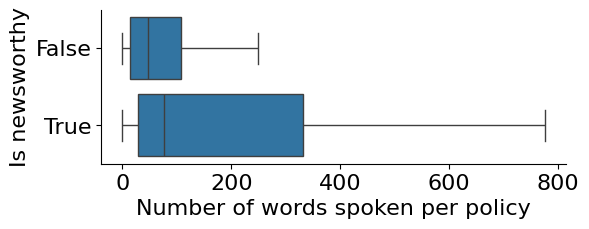

In [53]:
plt.rc('font', size=16)
_, ax = plt.subplots(figsize=(6, 2))
(
    full_filled_in_csvs_with_newsworthiness
        .assign(text_len=lambda df: 
                    df['transcribed_text']
                        .apply(lambda x: list(map(lambda y: y['text'], x)))
                        .str.join(' ')
                        .str.split().str.len()
        )
        .assign(label=lambda df: df['label'].astype(str))
        .pipe(lambda df: sns.boxplot(data=df, y='label', x='text_len', showfliers=False, ax=ax))
)
plt.xlabel('Number of words spoken per policy')
plt.ylabel('Is newsworthy')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False) 
plt.savefig('../latex/emnlp2023/figures/newsworthiness-time-spent.png', bbox_inches='tight')

# Model Newsworthiness

In [56]:
# downsample 
# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import CountVectorizer

class Featurizer(BaseEstimator, TransformerMixin):
    """Sklearn mixin to grab text."""
    def __init__(self, includes_speaker_text=False):
        self.includes_speaker_text = includes_speaker_text
        super().__init__()
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        ## if True, then it's just a series:
        if self.includes_speaker_text == False:
            return X.apply(lambda x: list(map(lambda y: y['text'], x))).str.join(' ')
        ## otherwise, it has two columns=['transcribed_text', 'speaker_text']
        else:
            transcribed_text = X['transcribed_text'].apply(lambda x: list(map(lambda y: y['text'], x))).str.join(' ')
            return (transcribed_text + ' ' + X['speaker_text'].fillna('')).str.strip()
            

    def fit_transform(self, X, y=None):
        return self.transform(X)

lr_pipe_newsworthiness = Pipeline([
    ('process_text', Featurizer()),
    ('tfidf', TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    # ('cv', CountVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    ('bal', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))
])

In [57]:
import glob
import pandas as pd 

In [58]:
orig_files_to_fetch = glob.glob('../data/city-council-meeting-minutes/all-links-to-pdfs-in-bay-area/*/san-fran*')
all_files_to_fetch = pd.concat(list(map(lambda x: pd.read_csv(x, index_col=0), orig_files_to_fetch)))

In [59]:
full_filled_in_csvs_with_newsworthiness_with_date = (
    full_filled_in_csvs_with_newsworthiness
        .merge(
                # orig_video_bos_files_to_fetch[['clip_id', 'date']],
                (all_files_to_fetch
                    .loc[lambda df: df['doc_type'] == 'Video']
                    .assign(clip_id=lambda df: df['url'].str.extract(r'clip/(\d+)', expand=False))
                    .loc[lambda df: df['clip_id'].notnull()]
                    .assign(clip_id=lambda df: df['clip_id'].astype(int))
                    [['clip_id', 'date']]
                ),
                on='clip_id',
                how='left'
        )
)

# get sample weights based on class imbalance
df_to_train = (
    full_filled_in_csvs_with_newsworthiness_with_date
        .loc[lambda df: df['date'].notnull()]
        .pipe(
            lambda df: df.merge(
                                df['label']
                                    .value_counts(normalize=True)
                                    .pipe(lambda s: 1-s)
                                    .to_frame('proportion')
                                    ,
                                left_on='label',
                                right_index=True
                    )
    )
)

In [64]:
full_filled_in_csvs_with_newsworthiness_with_date.to_json(
    'cache/training_data/full_newsworthiness_training_data.jsonl',
    orient='records',
    lines=True
)

In [38]:
ls cache/2024-03-25__retrieve-examples-for-demo

df_to_train_with_grouped_speakers.jsonl
full-meeting-data-with-headers.csv
full-meeting-data-with-headers.jsonl
full_newsworthiness_training_data.jsonl
public-speaker-embeddings.jsonl
sample-gpt3-scored-data__prior-meetings.jsonl


In [67]:
## split data and train model
test_df = df_to_train.loc[lambda df: df['date']  > '2021-01-01']
train_df = df_to_train.loc[lambda df: df['date']  <= '2021-01-01']
lr_pipe_newsworthiness.fit(
    X=train_df['transcribed_text'],
    y=train_df['label'].astype(int), 
    # lr__sample_weight=train_df['proportion']
)

Pipeline(steps=[('process_text', Featurizer()),
                ('tfidf',
                 TfidfVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('bal', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [68]:
y_prob = lr_pipe_newsworthiness.predict_proba(X=test_df['transcribed_text'])[:, 1]

In [69]:
f1_score(y_prob > .5, test_df['label'].astype(int))

0.17807456872565386

In [68]:
roc_auc_score(test_df['label'].astype(int), y_prob)

0.6542292089249493

In [69]:
## Try grouping together proposals that are discussed in multiple meetings

In [122]:
from more_itertools import flatten
df_to_train_grouped = (
    df_to_train
     .groupby('proposal_number')
     [['transcribed_text', 'label', 'date']]
     .aggregate(list)
     .assign(transcribed_text=lambda df: 
             df['transcribed_text']
                 .apply(lambda x: list(flatten(x)))
        )
    .assign(label=lambda df: df['label'].apply(any).astype(int))
    .loc[lambda df: df['date'].apply(lambda x: list(filter(lambda y: pd.notnull(y), x))).str.len() > 0]
    .assign(last_date=lambda df: df['date'].apply(max))
)

In [71]:
test_df = (
    df_to_train_grouped
        .loc[lambda df: df['last_date']  > '2021-01-01']
)
train_df = (
    df_to_train_grouped
        .loc[lambda df: df['last_date']  <= '2021-01-01']
)

In [ ]:
f1s = []
rocs = []
for _ in tqdm(range(5)):
    ## split data and train model
    lr_pipe_newsworthiness.fit(
        X=train_df['transcribed_text'],
        y=train_df['label'].astype(int), 
        # lr__sample_weight=train_df['proportion']
    )

    y_prob = lr_pipe_newsworthiness.predict_proba(X=test_df['transcribed_text'])[:, 1]
    f1 = f1_score(test_df['label'].astype(int), y_prob > .5)
    f1s.append(f1)

    roc = roc_auc_score(test_df['label'].astype(int), y_prob)
    rocs.append(roc)

In [ ]:
np.mean(f1s), np.var(f1s)

# Try matching public comment to the proposals

In [94]:
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

def group_speakers(public_comment):
    """Gather all the text from the same speaker together."""
    speaker_text = defaultdict(list)
    speaker_times = defaultdict(int)
    for p in public_comment:
        speaker_text[p['speaker']].append(p['text'])
        speaker_times[p['speaker']] += p['end'] - p['start']
    speaker_text = pd.Series(speaker_text)
    speaker_times = pd.Series(speaker_times)
    if len(speaker_text) > 0:
        speaker_text = speaker_text.str.join(' ').fillna('').str.strip()
    return speaker_text, speaker_times

In [95]:
full_filled_in_csvs_with_headers = (
    full_filled_in_csvs_with_headers
     .assign(speakers=lambda df: df.apply(lambda x: list(set(map(lambda y: y['speaker'], x['transcribed_text']))), axis=1))
)

In [259]:
full_filled_in_csvs_with_headers.to_json(
    'cache/training_data/full-meeting-data-with-headers.jsonl',
    lines=True,
    orient='records'
)

In [100]:
from more_itertools import flatten
col_order = [
    'COMMITTEE REPORT',
    'SPECIAL ORDER',
    'PUBLIC COMMENT',
    'CONSENT AGENDA',
    'NEW BUSINESS',
    'REGULAR AGENDA',
    'IMPERATIVE AGENDA',
    'FOR ADOPTION WITHOUT COMMITTEE REFERENCE',
    'UNFINISHED BUSINESS',
    'ROLL CALL',
    'PROPOSED RESOLUTION',
    'COMMUNICATION',
    'APPROVAL OF MEETING MINUTE',
    'AGENDA CHANGE',
    'PROPOSED ORDINANCE',
    'ADJOURNMENT',
#     'LEGISLATION UNDER THE 30-DAY RULE',
#     'LITIGATION',
]
(full_filled_in_csvs_with_headers
#      .assign(num_speakers=lambda df: df['speakers'].str.len())
     .groupby(['clip_id', 'header'])
     ['speakers'].aggregate(list)
     .apply(lambda x: list(set(flatten(x))))
     .str.len()
     .unstack()
#      .iloc[1]
     .fillna(0)
     .std()
     .loc[col_order]
     .round(0).astype(int)
)
(full_filled_in_csvs_with_headers
     .loc[lambda df: df['proposal_number'].notnull()]
     .drop_duplicates(['clip_id', 'header', 'proposal_number'])
     .value_counts(['clip_id', 'header'])
     .unstack()
     .fillna(0)
     .std()
     .round(1)
#      .astype(int)
     .loc[col_order]
)

header
COMMITTEE REPORT                            4.9
SPECIAL ORDER                               8.0
PUBLIC COMMENT                              1.0
CONSENT AGENDA                              4.2
NEW BUSINESS                                9.2
REGULAR AGENDA                              7.3
IMPERATIVE AGENDA                           3.3
FOR ADOPTION WITHOUT COMMITTEE REFERENCE    3.9
UNFINISHED BUSINESS                         6.4
ROLL CALL                                   3.1
PROPOSED RESOLUTION                         2.5
COMMUNICATION                               1.2
APPROVAL OF MEETING MINUTE                  1.0
AGENDA CHANGE                               1.2
PROPOSED ORDINANCE                          1.5
ADJOURNMENT                                 2.0
dtype: float64

In [101]:
all_speaker_texts = []
for public_comment in (
    full_filled_in_csvs_with_headers
#         .loc[lambda df: df['header'] == 'PUBLIC COMMENT']
        ['transcribed_text']
):
    speaker_text, speaker_times = group_speakers(public_comment)
    all_speaker_texts.append(speaker_text)

In [102]:
from collections import defaultdict

def group_speakers_across_meeting(meeting_df):
    speaker_to_header = defaultdict(set)
    for idx, (header, speakers) in meeting_df[['header', 'transcribed_text']].iterrows():
        for speaker in speakers:
            speaker_to_header[speaker['speaker']].add(header)
    
    public_comment_speakers = (
        pd.Series(speaker_to_header)
         .loc[lambda s: s.apply(lambda x: 'PUBLIC COMMENT' in x)]
         .loc[lambda s: s.str.len() == 1]
         .index
         .tolist()
    )
    public_comment = meeting_df.loc[lambda df: df['header'] == 'PUBLIC COMMENT']
    speaker_groups, time_groups = [], []
    for transcribed_text_block in public_comment['transcribed_text']:
        speaker_text, speaker_times = group_speakers(transcribed_text_block)
        speaker_groups.append(speaker_text)
        time_groups.append(speaker_times)
    speaker_text = pd.concat(speaker_groups)
    speaker_times = pd.concat(time_groups)
    return (
        speaker_text.loc[public_comment_speakers].dropna().groupby(level=0).aggregate(list).apply(lambda x: ' '.join(map(str, x))), 
        speaker_times.loc[public_comment_speakers].dropna().groupby(level=0).aggregate(list).apply(lambda x: ' '.join(map(str, x)))
    )

In [103]:
# alignment model
all_proposal_text = (
    full_filled_in_csvs_with_headers
        .loc[lambda df: df['proposal_number'].notnull()]
        ['text']
)
all_speaker_text = pd.concat(all_speaker_texts)
all_text = pd.concat([all_proposal_text, all_speaker_text])
cv = CountVectorizer(min_df=.001, max_df=.4, stop_words='english').fit(all_text)
all_vecs = cv.transform(all_text)

In [104]:
all_sims = cosine_similarity(
    all_vecs[:len(all_proposal_text)],
    all_vecs[len(all_proposal_text):]
)

In [105]:
all_sims_df = pd.DataFrame(all_sims).unstack().reset_index(drop=True)

In [106]:
all_sims_df.pipe(pd.cut, bins=10, ).value_counts()

(-0.001, 0.1]    1329989046
(0.1, 0.2]         39698368
(0.2, 0.3]          6690749
(0.3, 0.4]          1280018
(0.4, 0.5]           284137
(0.5, 0.6]            57788
(0.6, 0.7]            15722
(0.7, 0.8]             4145
(0.8, 0.9]              564
(0.9, 1.0]               63
Name: count, dtype: int64

In [107]:
all_sims_df.pipe(lambda s: s > .30).value_counts()

False    1376375267
True        1645333
Name: count, dtype: int64

In [108]:
## match proposal text to public comment text

In [109]:
matched_speaker_proposal_text = []
for clip_id in tqdm(full_filled_in_csvs_with_headers['clip_id'].drop_duplicates()):
    meeting_df = full_filled_in_csvs_with_headers.loc[lambda df: df['clip_id'] == clip_id]
    proposals_by_clip = (
        meeting_df
            .loc[lambda df: df['proposal_number'].notnull()]
            [['proposal_number', 'text']]
    )

    public_comment_by_clip = (
        meeting_df
            .loc[lambda df: df['header'] == 'PUBLIC COMMENT']
            ['transcribed_text']
    )    
    if len(proposals_by_clip) > 0 and (len(public_comment_by_clip) > 0) and (len(public_comment_by_clip.iloc[0]) > 0):
#         grouped_speaker_text, grouped_speaker_times = group_speakers_across_meeting(meeting_df)
        grouped_speaker_text, grouped_speaker_times = group_speakers(public_comment_by_clip.iloc[0])
        proposal_vecs = cv.transform(proposals_by_clip['text'])
        if grouped_speaker_text.shape[0] > 0:
            public_comment_vecs = cv.transform(grouped_speaker_text)
            sims = cosine_similarity( proposal_vecs, public_comment_vecs)
            sims_df = pd.DataFrame(sims, index=proposals_by_clip.index, columns=grouped_speaker_text.index)
            for s, p in sims_df.unstack().loc[lambda s: s> .15].index:
                matched_speaker_proposal_text.append({
                    'clip_id': clip_id,
                    'proposal_number': proposals_by_clip.loc[p, 'proposal_number'],
                    'speaker_text': grouped_speaker_text.loc[s],
                    'speaker_time': grouped_speaker_times.loc[s],
                    'proposal_text': proposals_by_clip.loc[p, 'text'],
                    'speaker_id': s,
                    'sim': sims_df.loc[p, s]
                })

  0%|          | 0/392 [00:00<?, ?it/s]

In [110]:
matched_speaker_proposal_text_df = pd.DataFrame(matched_speaker_proposal_text)

In [111]:
matched_speaker_proposal_text_df = (
    matched_speaker_proposal_text_df
     .loc[lambda df: df['sim'] > .25]
#      .drop_duplicates('speaker_text')
)

In [112]:
all_public_comment_counts = (full_meeting_row_df['File #']
 .drop_duplicates()
 .to_frame('proposal_number')
 .merge(matched_speaker_proposal_text_df
     ['proposal_number']
     .value_counts().to_frame('all_counts'),
        left_on='proposal_number',
        right_index=True,
        how='left',
)
)

newsworthy_public_comment_counts = (
    final_matching_df['File #']
         .drop_duplicates()
         .to_frame('proposal_number')
         .merge(
             matched_speaker_proposal_text_df['proposal_number'].value_counts().to_frame('all_counts'),
             left_on='proposal_number',
             right_index=True,
             how='left',
        )
)

NameError: name 'full_meeting_row_df' is not defined

In [ ]:
newsworthy_public_comment_counts['all_counts'].mean()

In [ ]:
all_public_comment_counts['all_counts'].mean()

<AxesSubplot:xlabel='all_counts', ylabel='group'>

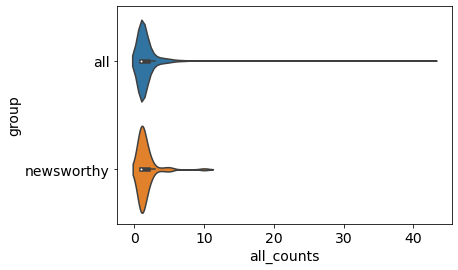

In [545]:
pd.concat([
    all_public_comment_counts.assign(group='all'),
    newsworthy_public_comment_counts.assign(group='newsworthy')
]).pipe(lambda df: sns.violinplot(data=df, x='all_counts', y='group', showfliers=False))

In [113]:
all_varied_text = pd.concat([
    ######
    all_meetings
         .sample(len(final_matching_df))
         .pipe(lambda x: x['Name'] + '. ' + x['Title'])
         .to_frame('text').assign(group='general policy'),
    ######
    final_matching_df['meeting text'].to_frame('text')
         .assign(group='newsworthy policy'),
    ###### 
    matched_speaker_proposal_text_df['speaker_text']
         .to_frame('text').assign(group='public comment speech'),
    ######
    full_transcribed_text_df['text']
         .loc[lambda s: s.str.len() > 200]
         .sample(1000)
         .to_frame('text').assign(group='general speech')
])

In [1031]:
cv = CountVectorizer(min_df=.001, max_df=.5, stop_words='english')
cv.fit(all_varied_text['text'])

CountVectorizer(max_df=0.5, min_df=0.001, stop_words='english')

In [1057]:
vocab = pd.Series(pd.Series(cv.vocabulary_).sort_values().index)

In [1094]:
(full_filled_in_csvs_with_newsworthiness
 .loc[lambda df: df['label']==True]
 .apply(lambda x: ' '.join(list(map(lambda y: y['text'], x['transcribed_text']))), axis=1)
)

57        The bar has been, just recently I helped to c...
124       Item 22 is an ordinance amending the health a...
556      This resolution is adopted. Item 11. Item 11 i...
558      Item 14 is an ordinance amending the planning ...
601      Colleagues, this is the second supplemental th...
                               ...                        
31708     Item 7 is a resolution to authorize the Human...
31713     Item 15, this is an ordinance to amend the Sa...
31714     Item 16 is a resolution to support the develo...
31771     Item 15, this is an ordinance to de-appropria...
31953     for approximately $48 million as a loan to Su...
Length: 1301, dtype: object

In [ ]:
generic_speaker_p = (
    matched_speaker_proposal_text_df
         ['speaker_text']
         .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
         .pipe(lambda s: s/s.sum())
)


newsworthy_speaker_p = (
    matched_speaker_proposal_text_df
         .loc[lambda df: df['proposal_number'].isin(final_matching_df['File #'])]    
         ['speaker_text']
         .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
         .pipe(lambda s: s/s.sum())
)

generic_policy_p = (
    all_meetings
         .dropna()
         .sample(len(final_matching_df))
         .pipe(lambda x: x['Name'] + '. ' + x['Title'])
         .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
         .pipe(lambda s: s/s.sum())
)

newsworthy_policy_p = (
    final_matching_df['meeting text']
         .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
         .pipe(lambda s: s/s.sum())
)

generic_meeting_p = (
    full_transcribed_text_df['text']
         .dropna()
         .loc[lambda s: s.str.len() > 200]
         .sample(1000)
         .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
         .pipe(lambda s: s/s.sum())                    
)

newsworthy_meeting_p = (
    full_filled_in_csvs_with_newsworthiness
        .loc[lambda df: df['label']==True]
        .apply(lambda x: ' '.join(list(map(lambda y: y['text'], x['transcribed_text']))), axis=1)
        .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
        .pipe(lambda s: s/s.sum())
)


non_newsworthy_meeting_p = (
    full_filled_in_csvs_with_newsworthiness
        .loc[lambda df: df['label']==False]
        .apply(lambda x: ' '.join(list(map(lambda y: y['text'], x['transcribed_text']))), axis=1)
        .pipe(lambda s: pd.Series(np.array(cv.transform(s).sum(axis=0))[0], index=vocab))
        .pipe(lambda s: s/s.sum())
)

In [ ]:
(generic_speaker_p - generic_policy_p).sort_values(ascending=False).head(10)

In [ ]:
(newsworthy_meeting_p - generic_meeting_p).sort_values(ascending=False).head(50)

In [1130]:
(
    (newsworthy_meeting_p - generic_policy_p)
        .sort_values(ascending=False).head(50).loc[[
             'supervisor',
             'think',
             'know',
             'want',
             'people',
             'like',
             'need',
             'president',
             'right',
             'madam',
#              'colleagues',
             'important',
            ]]
).to_dict()

{'supervisor': 0.01979530047357596,
 'think': 0.008906396769894314,
 'know': 0.008241919210413236,
 'want': 0.007808963761562435,
 'people': 0.007624374667293712,
 'like': 0.0057547000713687214,
 'need': 0.004287892151884785,
 'president': 0.003667473719339521,
 'right': 0.003392317576546236,
 'madam': 0.0028917511323566297,
 'important': 0.0017371184773117031}

In [1131]:
(newsworthy_speaker_p - generic_speaker_p).sort_values(ascending=False).head(50).loc[[
    'budget',
    'brandon',
    'cuba',
    'philippines',
    'solar',
    'medical',
    'covid',
    'caltrain',
    'rooms',
    'amendments',
    'shelter',
    'hotels',
    'crisis',
]].to_dict()

{'budget': 0.003974129598099804,
 'brandon': 0.002460874160739032,
 'cuba': 0.0019776967526834175,
 'philippines': 0.0015722561938055254,
 'solar': 0.0015366627420883403,
 'medical': 0.0014988859751233707,
 'covid': 0.0013649408477467385,
 'caltrain': 0.001356816749753661,
 'rooms': 0.001269077068834105,
 'amendments': 0.0012356669323647044,
 'shelter': 0.0011686943686763883,
 'hotels': 0.0010495755757857017,
 'crisis': 0.0009634100471158709}

In [997]:
matched_speaker_proposal_text_df.loc[lambda df: df['proposal_number'].isin(final_matching_df['File #'])]

,clip_id,proposal_number,speaker_text,speaker_time,proposal_text,speaker_id,sim
530,18628,130922.0,Civil discourse is a treasured and important t...,138.521,"130922 Collective Bargaining Agreement, Amendm...",SPEAKER_04,0.323290
669,20020,140457.0,"Good afternoon, supervisors. I'm Peter Warfiel...",125.671,140457 North Beach Branch Library Grand Openin...,SPEAKER_22,0.342368
909,21142,140906.0,"Thank you. Tom Gilberti, Two Townsend, South B...",133.045,140906 Settlement of Lawsuit - Eduardo Alegret...,SPEAKER_16,0.385534
910,21142,140905.0,"Thank you. Tom Gilberti, Two Townsend, South B...",133.045,140905 Settlement of Lawsuit - Sean Alexander ...,SPEAKER_16,0.298634
918,21316,141107.0,Good evening. My name is Jackie Flynn. I'm the...,93.052,141107 Solar Vision Goals for San Francisco by...,SPEAKER_08,0.680703
...,...,...,...,...,...,...,...
3095,38109,210216.0,"Hello, good evening. My name, President Walton...",130.953,210216 Administrative Code - Health Care Requi...,SPEAKER_21,0.274227
3379,40791,211295.0,I wanted to thank Mayor Breed for introducing ...,98.399,211295 Park Code - Admission Fees at the Garde...,SPEAKER_25,0.267660
3666,42577,221210.0,"Good afternoon, supervisors. My name is Shane ...",79.467,221210 Resolution of Intent to Not Appropriate...,SPEAKER_04,0.341713
3718,42651,221240.0,"Good evening, Supervisors. My name is Alan Bur...",33.226,"221240 Appointment, Police Commission",SPEAKER_68,0.273861


In [52]:
import pyperclip
with pd.option_context("max_colwidth", None):
    num_chars = 200
    t = (matched_speaker_proposal_text_df
         [['proposal_text', 'speaker_text']]#, 'speaker_time']]
#          .assign(speaker_time=lambda df: (df['speaker_time'] / 60).round(1).astype(str))
#          .assign(speaker_time=lambda df: (df['speaker_time'] / 60).round(1))         
         .assign(proposal_text=
                 lambda df: df['proposal_text'].apply(lambda x: x[:num_chars] + ('...' if len(x) > num_chars else '') )
                )
         .assign(speaker_text=
                 lambda df: df['speaker_text'].apply(lambda x: x[:num_chars] + ('...' if len(x) > num_chars else '') )
                )
         .head(20)
         .to_latex(index=False)
    )

    t = re.sub(' +', ' ', t)
    pyperclip.copy(t)

In [115]:
df_to_train_with_public_comment = (
    df_to_train
     .merge(
         matched_speaker_proposal_text_df[['clip_id', 'proposal_number', 'speaker_text']],
         left_on=['clip_id', 'proposal_number'],
         right_on=['clip_id', 'proposal_number'],
         how='left'
     )
)

In [117]:
(df_to_train_with_public_comment
 .assign(speaker_text=lambda df: df['speaker_text'].notnull())
 .groupby('label')['speaker_text'].mean()
)

label
False    0.041130
True     0.068216
Name: speaker_text, dtype: float64

In [118]:
lr_pipe_newsworthiness_with_speakers = Pipeline([
    ('process_text', Featurizer(includes_speaker_text=True)),
#     ('tfidf', TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    ('cv', CountVectorizer(min_df=.005, max_df=.5, stop_words='english')),
    ('bal', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))
])

In [551]:
test_df = df_to_train_with_public_comment.loc[lambda df: df['date']  > '2021-01-01']
train_df = df_to_train_with_public_comment.loc[lambda df: df['date']  <= '2021-01-01']

lr_pipe_newsworthiness_with_speakers.fit(
    X=train_df[['transcribed_text', 'speaker_text']],
    y=train_df['label'].astype(int)
)

Pipeline(steps=[('process_text', Featurizer(includes_speaker_text=True)),
                ('cv',
                 CountVectorizer(max_df=0.5, min_df=0.005,
                                 stop_words='english')),
                ('bal', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [552]:
y_prob = lr_pipe_newsworthiness_with_speakers.predict_proba(
    X=test_df[['transcribed_text', 'speaker_text']],
)[:, 1]

In [553]:
pd.Series( y_prob > .5).value_counts()

False    2664
True     1234
dtype: int64

In [554]:
f1_score(test_df['label'].astype(int), y_prob > .5)

0.1792828685258964

In [555]:
from more_itertools import flatten

In [561]:
(    df_to_train_with_public_comment
     .groupby('proposal_number')
     [['transcribed_text', 'speaker_text', 'label', 'date']]
 .aggregate(list)
      .assign(transcribed_text=lambda df: 
             df['transcribed_text']
                 .apply(lambda x: list(flatten(x)))
        )
      .assign(speaker_text=lambda df: df['speaker_text']
             .apply(lambda x: list(filter(lambda y: pd.notnull(y), x)))
             .apply(lambda x: ' '.join(x))
            )
.assign(label=lambda df: df['label'].apply(any).astype(int))

)

,transcribed_text,speaker_text,label,date
proposal_number,,,,
110548.0,[{'text': ' Item 20 is an ordinance to amend t...,,0,"[2015-02-03, 2015-02-10]"
111278.0,[{'text': 'I actually have a number of awards ...,,0,"[2013-06-04, 2013-06-11]"
120067.0,[{'text': ' Item 18 is a resolution determinin...,,0,[2013-03-05]
120125.0,[{'text': ' Item 21 is an ordinance amending t...,,0,"[2013-06-18, 2013-06-25]"
120193.0,[{'text': ' And item 23 is the ordinance amend...,,0,"[2013-06-18, 2013-06-25]"
...,...,...,...,...
230460.0,"[{'text': 'Item 32, please.', 'speaker': 'SPEA...",,0,[nan]
230461.0,[{'text': ' My honor same house same call the ...,,0,[nan]
230462.0,"[{'text': 'Mandelman, aye.', 'speaker': 'SPEAK...",,0,[nan]


In [564]:
df_to_train_with_public_comment['date'].isnull().value_counts()

False    17255
True       115
Name: date, dtype: int64

In [119]:
df_to_train_with_public_comment_condensed = (
    df_to_train_with_public_comment
    .loc[lambda df: df['date'].notnull()]
     .groupby('proposal_number')
     [['transcribed_text', 'speaker_text', 'label', 'date']]
     .aggregate(list)
     .assign(transcribed_text=lambda df: 
             df['transcribed_text']
                 .apply(lambda x: list(flatten(x)))
        )
     .assign(speaker_text=lambda df: df['speaker_text']
             .apply(lambda x: list(filter(lambda y: pd.notnull(y), x)))
             .apply(lambda x: ' '.join(x))
            )
    .assign(label=lambda df: df['label'].apply(any).astype(int))
    .assign(last_date=lambda df: df['date'].apply(max))
)

In [568]:
(
    df_to_train_with_public_comment_condensed
         .assign(num_days = lambda df: df['date'].str.len())
         .groupby('label')['num_days']
         .mean()
)

label
0    1.541836
1    1.567568
Name: num_days, dtype: float64

In [120]:
test_df = (
    df_to_train_with_public_comment_condensed
        .loc[lambda df: df['last_date']  > '2021-01-01']
)
train_df = (
    df_to_train_with_public_comment_condensed
        .loc[lambda df: df['last_date']  <= '2021-01-01']
)

In [571]:
f1s = []
rocs = []
for _ in tqdm(range(5)):
    lr_pipe_newsworthiness_with_speakers.fit(
        X=train_df[['transcribed_text', 'speaker_text']],
        y=train_df['label'].astype(int)
    )

    y_prob = lr_pipe_newsworthiness_with_speakers.predict_proba(
        X=test_df[['transcribed_text', 'speaker_text']],
    )[:, 1]

    f1 = f1_score(test_df['label'].astype(int), y_prob > .5)
    roc = roc_auc_score(test_df['label'].astype(int), y_prob)
    f1s.append(f1)
    rocs.append(roc)

  0%|          | 0/5 [00:00<?, ?it/s]

In [573]:
np.mean(f1s), np.var(f1s)

(0.18472260692088932, 6.01136324076945e-05)

In [574]:
## another way to condense

In [123]:
df_to_train_with_grouped_speakers = (
    df_to_train_grouped
    .reset_index()
    .merge(
        (matched_speaker_proposal_text_df
         .groupby(['clip_id', 'proposal_number'])
         [['speaker_text', 'speaker_time', 'speaker_id']]
         .aggregate(list)
         .assign(num_speakers=lambda df: df['speaker_id'].str.len())
         .reset_index()
        ),
        right_on='proposal_number',
        left_on='proposal_number',
        how='left'
    )
    .drop(columns=['speaker_id', 'clip_id'])
    .assign(num_speakers=lambda df: df['num_speakers'].fillna(0))
    .assign(speaker_text=lambda df: df['speaker_text'].apply(lambda x: [] if isinstance(x, float) else x))
)

In [106]:
(df_to_train_with_grouped_speakers
     .fillna(0)
     .assign(num_speakers=lambda df: df['num_speakers'] > 0)
     .groupby('label')['num_speakers']
     .mean()
)

label
0    0.039841
1    0.065805
Name: num_speakers, dtype: float64

In [124]:
test_df = (
    df_to_train_with_grouped_speakers
        .loc[lambda df: df['last_date']  > '2021-01-01']
)
train_df = (
    df_to_train_with_grouped_speakers
        .loc[lambda df: df['last_date']  <= '2021-01-01']
)

In [125]:
df_to_train_with_grouped_speakers.head(2)

,proposal_number,transcribed_text,label,date,last_date,speaker_text,speaker_time,num_speakers
0,110548.0,[{'text': ' Item 20 is an ordinance to amend t...,0,"[2015-02-03, 2015-02-10]",2015-02-10,[],NaN,0.0
1,111278.0,[{'text': 'I actually have a number of awards ...,0,"[2013-06-04, 2013-06-11]",2013-06-11,[],NaN,0.0


In [685]:
lr_pipe_for_grouped_speakers = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english')),
#     ('cv', CountVectorizer(min_df=.005, max_df=.5, stop_words='english')),
    ('bal', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))
])
lr_pipe_for_grouped_speakers.fit(
        X=(
            train_df['transcribed_text']
                .apply(lambda x: list(map(lambda y: y['text'], x)))
                .apply(lambda x: ' '.join(x))
                + 
            train_df['speaker_text'].str.join(' ')
        ),
        y=train_df['label'].astype(int)
    )

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('bal', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [686]:
y_prob = lr_pipe_for_grouped_speakers.predict_proba(
            test_df['transcribed_text']
                .apply(lambda x: list(map(lambda y: y['text'], x)))
                .apply(lambda x: ' '.join(x))
                + 
            test_df['speaker_text'].str.join(' ')
        )[:, 1]

In [688]:
f1_score(test_df['label'], y_prob > .5)

0.17729393468118196

In [127]:
df_to_train_with_grouped_speakers.to_json('cache/training_data/df_to_train_with_grouped_speakers.jsonl', orient='records',lines=True)

# Replicate Earlier Results

In [74]:
all_meetings = pd.read_csv('cache/2023-04-13__full_meeting_row_df.csv')

In [76]:
def get_path(url):
    if ')' in url:
        return url.split(')')[-1]
    else:
        return (
            url
            .replace('www.', '')
            .replace('https', 'http')
            .replace('http://sfchronicle.com', '')
        )

In [77]:
from scipy.optimize import linear_sum_assignment

In [78]:
# positive_examples = (final_matching_df
#  .assign(article_url=lambda df: df['article_url'].apply(get_path))
#  .drop_duplicates(['File #', 'article_url'])
#  .drop(columns=['summary_text', 'article_url', 'article_publish_date'])
# )

train_cutoff_date = '2021-01-01'
all_meetings['meeting text'] = all_meetings['Name'] + ' ' + all_meetings['Title']
all_meetings['meeting date'] = all_meetings['date']
pre_train_df = all_meetings.loc[lambda df: df['date'] < train_cutoff_date]
pre_test_df =  all_meetings.loc[lambda df: df['date'] >= train_cutoff_date]

positive_examples = pre_train_df.loc[lambda df: df['File #'].isin(final_matching_df['File #'])]
positive_examples = positive_examples.drop_duplicates(['File #', 'meeting text']).drop(columns=['date'])
negative_examples = pre_train_df.loc[lambda df: ~df['File #'].isin(final_matching_df['File #'])]
negative_examples = (
    negative_examples
        .drop(columns=[
#             'Name', 'Title', 
            'date'
        ])
        .drop_duplicates(['File #', 'meeting text'])
)

# get negative examples based on similarity

if False:
    tfidf = TfidfVectorizer(min_df=.01, max_df=.4, stop_words='english')
    tfidf.fit(pre_train_df.pipe(lambda df: df['Name'] + ' ' + df['Title']).fillna(''))
    pos_vecs = tfidf.transform(positive_examples['meeting text'])
    neg_vecs = tfidf.transform(negative_examples['meeting text'].fillna(''))
    sim_df = pd.DataFrame(
        cosine_similarity(pos_vecs, neg_vecs),
        index=positive_examples.index,
        columns=negative_examples.index
    )

    r,c = linear_sum_assignment( sim_df, maximize=True)
    negative_examples = negative_examples.loc[sim_df.columns[c]]
else:
    negative_examples = negative_examples.sample(len(positive_examples))

In [79]:
train_df['label'].value_counts()
test_df['label'].value_counts()

label
False    3537
True      272
Name: count, dtype: int64

In [80]:
pre_train_df.drop_duplicates(['File #', 'meeting text']).shape

(10179, 8)

In [81]:
pre_test_df.drop_duplicates(['File #', 'meeting text']).shape 

(3029, 8)

In [82]:
negative_examples.shape 

(798, 7)

In [83]:
pre_train_df = pd.concat([positive_examples.assign(label=1), negative_examples.assign(label=0)]).dropna()
pre_test_df = (
    all_meetings
        .loc[lambda df: df['meeting date'] > '2021-01-01']
        .drop_duplicates(['File #', 'meeting text'])
        .assign(label=lambda df: df['File #'].isin(final_matching_df['File #']).astype(int))
)

In [84]:
# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline

lr_pipe_meeting_newsworthiness = Pipeline([
#     ('process_text', Featurizer()),
    ('tfidf', TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    # ('cv', CountVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    ('bal', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))
])

In [85]:
f1s = []
rocs = []

from tqdm.auto import tqdm
for _ in tqdm(range(2)):
    lr_pipe_meeting_newsworthiness.fit(pre_train_df['meeting text'], pre_train_df['label'])
    y_prob = lr_pipe_meeting_newsworthiness.predict_proba(pre_test_df['meeting text'])[:, 1]
    f1 = f1_score(pre_test_df['label'], y_prob > .5)
    f1s.append(f1)
    roc = roc_auc_score(pre_test_df['label'], y_prob > .5)
    rocs.append(roc)

  0%|          | 0/2 [00:00<?, ?it/s]

In [86]:
import numpy as np 
np.mean(f1s), np.var(f1s)

(0.22570844514379645, 8.794743579517939e-07)

In [87]:
np.mean(rocs), np.var(rocs)

(0.6638429342632219, 1.9275452216503195e-06)

In [ ]:
(test_df
 .assign(pred=y_prob > .5)
 .pipe(lambda df: print(classification_report(df['label'], df['pred'])))
)

# Try to combine everything

In [91]:
dates_by_policy = pd.concat([
    (final_matching_df
         .assign(**{'meeting date':lambda df: pd.to_datetime(df['meeting date'])})
         .groupby('File #')['meeting date']
         .aggregate(list)
         .to_frame('news_coverage_dates')
    ),
    (all_meetings
         .assign(date=lambda df: pd.to_datetime(df['date']))
         .groupby('File #')['date']
         .aggregate(list)
         .to_frame('policy_meeting_dates')
    )
], axis=1).assign(news_coverage_dates=lambda df: df['news_coverage_dates'].apply(lambda x: [] if isinstance(x, float) else x ))

In [128]:
data_df_with_all_text = (
    pd.concat([pre_train_df, pre_test_df]).drop_duplicates(['File #', 'meeting text'])
     .merge(
         df_to_train_with_grouped_speakers.drop(columns='label').drop(columns='date'),
         left_on=['File #'],
         right_on=['proposal_number'],
#          how='left'
     )
     .drop(columns=['proposal_number'])
     .assign(transcribed_time_in_minutes=
                lambda df: df['transcribed_text']
                     .apply(lambda x: [] if isinstance(x, float) else x)
                     .apply(lambda x: sum(map(lambda y: y['end'] - y['start'], x)) / 60)
            )
    .assign(transcribed_num_speakers=lambda df:
            df['transcribed_text']
                .apply(lambda x: [] if isinstance(x, float) else x)
                .apply(lambda x: len(set(map(lambda y: y['speaker'], x)))))
    .assign(transcribed_text=lambda df: 
         df['transcribed_text']
            .apply(lambda x: [] if isinstance(x, float) else x)
            .apply(lambda x: ' '.join(list(map(lambda y: y['text'], x))).strip())
    )
    .assign(num_meetings=lambda df: df['meeting date'].str.len())
    .rename(columns={'num_speakers': 'public_comment_num_speakers', 'speaker_time': 'public_comment_speaker_time'})
    .assign(public_comment_speaker_time=lambda df: df['public_comment_speaker_time'].fillna(0))
    .drop(columns=['city', 'committee'])
#      .assign(speaker_text=lambda df: df['speaker_text'].str.join(' '))
)

data_df_with_all_text = (data_df_with_all_text
 .merge(dates_by_policy, left_on='File #', right_index=True)
 .assign(**{'meeting date':lambda df: pd.to_datetime(df['meeting date'])})
 .assign(prior_news_coverage=
   lambda df: 
     df.apply(lambda x: list(filter(lambda y: y < x['meeting date'], x['news_coverage_dates'])), axis=1).str.len()
  )
 .assign(prior_meetings=
   lambda df: 
     df.apply(lambda x: list(filter(lambda y: y < x['meeting date'], x['policy_meeting_dates'])), axis=1).str.len()
    )
)

train_df = data_df_with_all_text.loc[lambda df: df['meeting date'] <= '2021-01-01']
test_df = data_df_with_all_text.loc[lambda df: df['meeting date'] > '2021-01-01']

In [116]:
lr_pipe_all_newsworthiness = Pipeline([
#     ('tfidf', TfidfVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    ('cv', CountVectorizer(min_df=.001, max_df=.5, stop_words='english')),
#     ('bal', RandomUnderSampler()),
    ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))
])

In [1351]:
lr_pipe_all_newsworthiness.fit(X=train_df['meeting text'], y=train_df['label'])

Pipeline(steps=[('cv',
                 CountVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('bal', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [1352]:
y_prob = lr_pipe_all_newsworthiness.predict_proba(test_df['meeting text'])[:, 1 ]

In [1353]:
f1_score(y_prob > .5, test_df['label'])

0.1402483564645727

In [1354]:
roc_auc_score(test_df['label'], y_prob)

0.5486350884764782

In [1355]:
lr_pipe_all_newsworthiness.fit(
    X=train_df['meeting text'] + ' ' + train_df['transcribed_text'], 
    y=train_df['label']
)

Pipeline(steps=[('cv',
                 CountVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('bal', RandomUnderSampler()),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [1356]:
y_proba_2 = lr_pipe_all_newsworthiness.predict_proba(
    X=test_df['meeting text'] + ' ' + test_df['transcribed_text'], 
)[:, 1]

In [1357]:
f1_score(test_df['label'], y_proba_2 > .5)

0.2135076252723312

In [1358]:
roc_auc_score(test_df['label'], y_proba_2)

0.6248780281848718

In [1359]:
def get_first_n_words(s, n=200):
    return s.str.split(' ').apply(lambda x: x[:n]).str.join(' ')

# lr_pipe_all_newsworthiness.fit(
#     X=
#     train_df['meeting text'] + ' ' 
#     + train_df['transcribed_text'].pipe(get_first_n_words) + ' '
#     + train_df['speaker_text'].str.join(' ').pipe(get_first_n_words), 
#     y=train_df['label']
# )

In [1360]:
y_proba_3 = lr_pipe_all_newsworthiness.predict_proba(
    X=test_df['meeting text'] + ' ' 
    + test_df['transcribed_text'].pipe(get_first_n_words) + ' ' 
    + test_df['speaker_text'].str.join(' ').pipe(get_first_n_words), 
)[:, 1]

In [1361]:
f1_score(test_df['label'], y_proba_3 > .5)

0.05286343612334802

In [1362]:
roc_auc_score(test_df['label'], y_proba_3)

0.6013773432662177

# Produce output for GPT-training

In [920]:
from transformers import AutoTokenizer

In [921]:
tok = AutoTokenizer.from_pretrained('gpt2')

In [923]:
tok_lens = (
    (test_df['meeting text'] + ' ' + test_df['transcribed_text'] + ' ' + test_df['speaker_text'].str.join(' '))
    .apply(lambda x: len(tok.encode(x)))
)

Token indices sequence length is longer than the specified maximum sequence length for this model (11347 > 1024). Running this sequence through the model will result in indexing errors


In [924]:
tok_lens.pipe(lambda s: s > 2048).value_counts()

False    2312
True      139
dtype: int64

In [612]:
pd.concat([tok_lens, test_df['label']], axis=1).groupby('label').median()

,0
label,
0,267.0
1,397.5


In [613]:
test_df.assign(t_len=lambda df: df['meeting text'].str.len()).groupby('label')['t_len'].median()

label
0    465.0
1    502.5
Name: t_len, dtype: float64

In [614]:
test_df.assign(t_len=lambda df: (df['meeting text'] + df['transcribed_text']).str.len()).groupby('label')['t_len'].median()

label
0    1234.0
1    1896.5
Name: t_len, dtype: float64

In [616]:
test_df.assign(t_len=lambda df:
               (df['meeting text'] + df['transcribed_text'] + df['speaker_text'].str.join(' ')).str.len()).groupby('label')['t_len'].median()

label
0    1275.0
1    1942.5
Name: t_len, dtype: float64

In [112]:
train_df['label'].value_counts().sum()

1303

In [130]:
bal_train_df = (
    train_df
     .pipe(lambda df:
            pd.concat([
                df.loc[lambda df: df['label'] == 1],
                df.loc[lambda df: df['label'] == 0].sample(
                    min(len(df.loc[lambda df: df['label'] == 1]), len(df.loc[lambda df: df['label'] == 0]))),
            ])
        )
     .sample(frac=1)
)

In [235]:
lr_pipe_all_newsworthiness.fit(
    X=bal_train_df['meeting text'] + ' ' + bal_train_df['transcribed_text'] + ' ' + bal_train_df['speaker_text'].str.join(' ').fillna(''), 
    y=bal_train_df['label']
)

Pipeline(steps=[('cv',
                 CountVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [236]:
y_proba_4 = lr_pipe_all_newsworthiness.predict_proba(
    X=test_df['meeting text'] + ' ' + test_df['transcribed_text'] + ' ' + test_df['speaker_text'].str.join(' ').fillna(''), 
)[:, 1]

In [237]:
f1_score(test_df['label'], y_proba_4 > .5)

0.2165058949624866

In [238]:
roc_auc_score(test_df['label'], y_proba_4)

0.6659788359788359

In [251]:
def make_prompt(x, include_proposal, include_meeting_discussion, include_public_comment):
    output_prompt = ''
    
    # instruction
    if include_proposal:
        output_prompt += 'Policy description:\n\n'
        output_prompt += '```' + x['meeting text'] + '```' + '\n\n'
        output_prompt += f'Num prior meetings: {x["prior_meetings"]}'
    
    # meeting discussion
    if include_meeting_discussion:
        output_prompt += f'Introduced by {x["transcribed_num_speakers"]} speakers in the meeting for {round(x["transcribed_time_in_minutes"], 1)} minutes:\n\n'
        transcribed_words = x['transcribed_text'].split()
        if len(transcribed_words) > 150:
            output_prompt += '```[Excerpt:] ' + ' '.join(transcribed_words[:150]) + '...```' + '\n\n'
        else:
            output_prompt += '```' + ' '.join(transcribed_words) + '```' + '\n\n'

    # public comment
    if include_public_comment:
        num_speakers = x["public_comment_num_speakers"] if pd.notnull(x["public_comment_num_speakers"]) else 0
        output_prompt += f'{int(num_speakers)} members of the public spoke'
        if x['public_comment_num_speakers'] > 0:
            speaker_text_list = []
            for idx, (time, text) in enumerate(zip(x['public_comment_speaker_time'], x['speaker_text'])):
                words = text.split()
                text = ' '.join(words[:100]) + ('...' if len(words) > 100 else '')
                speaker_text_list.append( f'<SPEAKER {idx + 1}> spoke for {round(time/60)} minutes and said: "{text}".')
            output_prompt += f' for {round(sum(x["public_comment_speaker_time"])/ 60)} minutes.\n'
            output_prompt += '\n'.join(speaker_text_list)
        else:
            output_prompt += '.'
        
    # 
    output_prompt += '\n\nIs this newsworthy?'
    return output_prompt

In [228]:
bal_train_df['prompt'] = bal_train_df.apply(
    make_prompt, 
    include_proposal=True,
    include_meeting_discussion=True, 
    include_public_comment=True, 
    axis=1
)

In [324]:
bal_train_df['meeting date']#.isnull().value_counts()#.loc[lambda df: df['last_date'].dt.year < 2020]

795    2013-02-05
1000   2016-01-11
507    2019-07-16
670    2015-12-08
1034   2019-06-25
          ...    
478    2019-10-22
764    2014-07-15
1060   2016-06-14
292    2020-12-08
1343   2020-08-18
Name: meeting date, Length: 1595, dtype: datetime64[ns]

In [328]:
######## 
bal_train_df['prompt'] = bal_train_df.apply(
    make_prompt, 
    include_proposal=True,
    include_meeting_discussion=True, 
    include_public_comment=True, 
    axis=1
)
bal_train_df['completion'] = bal_train_df['label'].map({0: 'No', 1: 'Yes'})
with open('cache/gpt_training/gpt3-training-full__prior-meeting-info__prior-2017.jsonl', 'w') as f:
    for obj in (
        bal_train_df
        .loc[lambda df: df['meeting date'].dt.year < 2017]
        [['prompt', 'completion']]
        .to_dict(orient='records')
    ):
        f.write(json.dumps(obj) + '\n')

###########
bal_train_df['prompt'] = bal_train_df.apply(
    make_prompt, 
    include_proposal=True,
    include_meeting_discussion=True, 
    include_public_comment=False, 
    axis=1
)
bal_train_df['completion'] = bal_train_df['label'].map({0: 'No', 1: 'Yes'})
with open('cache/gpt_training/gpt3-training-no-public-comment__prior-meeting-info.jsonl', 'w') as f:
    for obj in (bal_train_df
#                 .loc[lambda df: df['last_date'].dt.year < 2018]
                [['prompt', 'completion']]
                .to_dict(orient='records')
               ):
        f.write(json.dumps(obj) + '\n')

        
######### 
bal_train_df['prompt'] = bal_train_df.apply(
    make_prompt, 
    include_proposal=True,
    include_meeting_discussion=False, 
    include_public_comment=False, 
    axis=1
)

bal_train_df['completion'] = bal_train_df['label'].map({0: 'No', 1: 'Yes'})
with open('cache/gpt_training/gpt3-training-no-meeting-info__prior-meeting-info.jsonl', 'w') as f:
    for obj in (bal_train_df
#                 .loc[lambda df: df['last_date'].dt.year < 2018]
                [['prompt', 'completion']]
                .to_dict(orient='records')
               ):
        f.write(json.dumps(obj) + '\n')        


###########
bal_train_df['prompt'] = bal_train_df.apply(
    make_prompt, 
    include_proposal=False,
    include_meeting_discussion=True, 
    include_public_comment=True, 
    axis=1
)

bal_train_df['completion'] = bal_train_df['label'].map({0: 'No', 1: 'Yes'})
with open('cache/gpt_training/gpt3-training-only-meeting-and-public-comment-info__prior-meeting-info.jsonl', 'w') as f:
    for obj in (bal_train_df
#                 .loc[lambda df: df['last_date'].dt.year < 2018]
                [['prompt', 'completion']]
                .to_dict(orient='records')
               ):
        f.write(json.dumps(obj) + '\n')        

<AxesSubplot:xlabel='prompt_len', ylabel='label'>

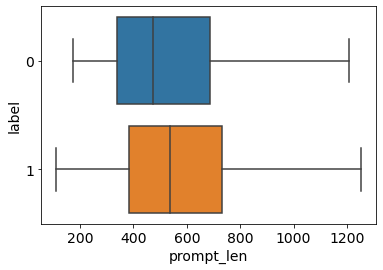

In [1320]:
bal_train_df['prompt'] = bal_train_df.apply(
    make_prompt, 
    include_proposal=True,
    include_meeting_discussion=False, 
    include_public_comment=False, 
    axis=1
)

(bal_train_df
 .assign(prompt_len=lambda df: df['prompt'].str.len())
 .assign(label=lambda df: df['label'].astype(str))
 .pipe(lambda df: sns.boxplot(data=df, x='prompt_len', y='label', showfliers=False))
#  .groupby('label')['prompt_len'].mean()
)

In [ ]:
! pip install openai

In [247]:
import openai

In [248]:
openai.api_key_path = '/Users/spangher/.openai-isi-key.txt'

In [ ]:
# full : ft-WCtAIRscTZljoqn1itxOeTfy
# full : babbage:ft-isi-nlp-2023-06-21-00-48-46

# full (ada): ft-T5SKCH7HLzLscqhxQN87PzrZ
# full : ada:ft-isi-nlp-2023-06-21-03-46-46

# full prior 2019: ft-kbwOUrf1mZuQwuCM2fwTwbZL
# full: babbage:ft-isi-nlp-2023-06-21-04-33-36

# full prior 2018: babbage:ft-isi-nlp-2023-06-21-05-07-34
# full reprocessed: ft-b8DKAqtth3jztOZPPB0fxTn2
#                   babbage:ft-isi-nlp-2023-06-21-15-28-47
#                   ft-xXvTvSdc7HYSCr8wro8jTqWU
#                   babbage:ft-isi-nlp-2023-06-22-01-42-36
#                   ft-ma8FCc9oveERN9tuGPLDc5YT
#                   babbage:ft-isi-nlp-2023-06-22-02-57-33 
# 

# full similarity match: ft-HAdYnhZKZ40HGH16sV6ZtBfl
#                        babbage:ft-isi-nlp-2023-06-21-21-36-16
# full prior 2019: ft-kdaIdhSYdJ9jLd3EtrCD6EJY
# full prior 2018: ft-Hh3YozOp7yo8iiWJ1QBSJY0C
# 
# full with prior meeting coverage
# babbage:ft-isi-nlp-2023-06-22-03-37-17

# 2017: ft-OywdNmjK9yjK9JASirGsC0oL
#            babbage:ft-isi-nlp-2023-06-22-04-23-46
# 2018: ft-T3FfOPAHc0OiSz0ZBkJyKebr
#            babbage:ft-isi-nlp-2023-06-22-04-35-00
# 2019: ft-TeeOLIR6O69BVDKN8g3gLWUd
#            babbage:ft-isi-nlp-2023-06-22-04-50-25
# 2020: ft-gu9oVaUV7h7ZJ5uXuDWjV06s
#            babbage:ft-isi-nlp-2023-06-22-05-13-58



# ------------------------------------------------------------------------------------------------------------

# no meeting info: ft-g06YdRe71YJGjvEeGpGWLRpZ
#                  babbage:ft-isi-nlp-2023-06-21-01-07-22
# no meeting info prior 2018: ft-Hru0PcAZXCHm1aIdH8Mf1q5L
# no meeting info: similarity matched: ft-uXwEyJiFaUx5N2CwbUvGbjZQ
#                                      babbage:ft-isi-nlp-2023-06-21-18-13-18

# no meeting info reprocessed: ft-VJmoySZ1Gk7pT7hYsz5jSiKL
#                                babbage:ft-isi-nlp-2023-06-22-02-00-24


# ------------------------------------------------------------------------------------------------------------

# no public comment: ft-f0xkw6xfcqvHVpjEP3OkvXqn
# no public comment prior 2018: ft-bjMPTapJiljPy7VkHCJoIrhR
# no public comment: similarity matched: ft-H303gZPYsH3BsQa8YZHnUJiI
#                                        babbage:ft-isi-nlp-2023-06-21-19-37-40
# no public comment: reprocessed: ft-gKUoomFlyyXlM5ZXMeyqSAbd
#                                   babbage:ft-isi-nlp-2023-06-22-02-19-09

# ------------------------------------------------------------------------------------------------------------

# only meeting info: ft-Vi1Z1Y6VFvhw9zdXgQhrtwvz
#                  babbage:ft-isi-nlp-2023-06-21-01-50-49
# only meeting info, prior 2018:  ft-vrMK4Gmn4JWFexSXx1OrcKld
# only meeting info: similarity matched: ft-6oMezhSSXgZ9nxLzmdScZ6y5
#                                        babbage:ft-isi-nlp-2023-06-21-20-23-30          
# only meeting info: reprocessed: ft-4HWGaph2azEDKJLKV700Mrd1
#                                      babbage:ft-isi-nlp-2023-06-22-02-37-42

# ! openai api fine_tunes.follow -i ft-g06YdRe71YJGjvEeGpGWLRpZ

In [676]:
smaller_sample = pd.concat([
    test_df.loc[lambda df: df['label'] == 0].sample(200),
    test_df.loc[lambda df: df['label'] == 1]
])

In [509]:
message=[{"role": "user", "content": 'hello'}]
response = openai.ChatCompletion.create(
    model="gpt-4",
    messages = message,
    temperature=0.2,
    max_tokens=1000,
    frequency_penalty=0.0
)
print(response)

{
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "content": "Hello! How can I help you today?",
        "role": "assistant"
      }
    }
  ],
  "created": 1687457312,
  "id": "chatcmpl-7UJ1MmTZys6JvTty8xdw5dwzmkFP4",
  "model": "gpt-4-0314",
  "object": "chat.completion",
  "usage": {
    "completion_tokens": 9,
    "prompt_tokens": 8,
    "total_tokens": 17
  }
}


In [587]:
def query_model(prompt, model_id, max_tokens=50):
    if model_id == 'gpt-4':
        response = openai.ChatCompletion.create(
            model=model_id,
            messages=[{"role": "user", "content": prompt + ' Answer with "yes" or "no".'}],
            max_tokens=5,
        )
    else:
        response = openai.Completion.create(
            engine=model_id,
            prompt=prompt,
            max_tokens=max_tokens,
            n=5,
            stop=None,
            logprobs=5,
            temperature=0.5,
        )
    return response.to_dict_recursive()

In [1199]:
lr_pipe_all_newsworthiness.fit(bal_train_df['prompt'], bal_train_df['label'])

Pipeline(steps=[('cv',
                 CountVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('lr', LogisticRegressionCV(Cs=50, max_iter=2000))])

In [1204]:
y_probs = lr_pipe_all_newsworthiness.predict_proba(test_df.apply(make_prompt, include_proposal=True,
        include_meeting_discussion=True,
        include_public_comment=True, axis=1))[:, 1]

In [1171]:
output = []
for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    p = make_prompt(
        row,
        include_proposal=False,
        include_meeting_discussion=True,
        include_public_comment=True
    )
    p = p[:2048]

    r = query_model(p, 'babbage:ft-isi-nlp-2023-06-22-02-37-42', max_tokens=1)
    output.append(r)
    if idx == 500:
        break

  0%|          | 0/2490 [00:00<?, ?it/s]

In [184]:
ls cache/2023-06*

cache/2023-06-20__ada-gpt3-full-answer-df.pkl
cache/2023-06-20__gpt3-full-answer-df.pkl
cache/2023-06-20__gpt3-full-answer-df__prior-2018.pkl
cache/2023-06-20__gpt3-full-answer-df__prior-2019.pkl
cache/2023-06-20__gpt3-sans-meetings-or-public-comment-df.pkl
cache/2023-06-20__gpt3-sans-policy-info-df.pkl
cache/2023-06-21__gpt3-full-answer-df__gpt-3.5.pkl
cache/2023-06-21__gpt3-full-answer-df__gpt-4.pkl
cache/2023-06-21__gpt3-full-answer-df__no-meeting-info__reprocessed.pkl
cache/2023-06-21__gpt3-full-answer-df__no-policy-text__reprocessed.pkl
cache/2023-06-21__gpt3-full-answer-df__no-prior-meetings.pkl
cache/2023-06-21__gpt3-full-answer-df__no-public-comment__reprocessed.pkl
cache/2023-06-21__gpt3-full-answer-df__prior-meetings.pkl
cache/2023-06-21__gpt3-full-answer-df__prior-meetings__prior-2017.pkl
cache/2023-06-21__gpt3-full-answer-df__prior-meetings__prior-2018.pkl
cache/2023-06-21__gpt3-full-answer-df__prior-meetings__prior-2019.pkl
cache/2023-06-21__gpt3-full-answer-df__prior-meet

In [233]:
answer_df = pd.read_pickle('cache/2023-06-21__gpt3-full-answer-df__prior-meetings.pkl')

In [1118]:
# answer_df.to_pickle('cache/2023-06-20__gpt3-sans-policy-info-df.pkl')

In [1173]:
answer_df.to_pickle('cache/2023-06-21__gpt3-full-answer-df__no-policy-text__reprocessed.pkl')

In [1172]:
answer_df = pd.DataFrame(list(map(lambda x: x['choices'][0], output)))

In [686]:
answer_df = pd.read_pickle('cache/2023-06-21__gpt3-full-answer-df__prior-meetings.pkl')

In [451]:
# answer_df.to_pickle('cache/2023-06-20__ada-gpt3-full-answer-df.pkl')

In [615]:
# answer_df.to_pickle('cache/2023-06-21__gpt3-full-answer-df__gpt-3.5.pkl')

In [452]:
# answer_df.to_pickle('cache/2023-06-21__gpt3-full-answer-df__prior-meetings__prior-2020.pkl')

In [482]:
# answer_df = pd.read_pickle('cache/2023-06-21__gpt3-full-answer-df__no-prior-meetings.pkl')

In [453]:
# answer_df.to_pickle('cache/2023-06-21__gpt3-full-answer-df__prior-meetings.pkl')
# answer_df.to_pickle('cache/2023-06-21__gpt3-full-answer-df__similarity-matched.pkl')
# answer_df.to_pickle('cache/2023-06-21__gpt3-no-meeting-info__similarity-matched.pkl')

In [195]:
year_level_df = pd.DataFrame([
{'year': 2017,
'f1': 0.17878426698450536,
'roc': 0.6610918710918711 ,
'mrr': 0.2205533197645503,
'R@10': 94 / 180,},
{'year': 2018,
'f1': 0.19506726457399104,
'roc': 0.6781793854990552,
'mrr': 0.2288135019855793,
'R@10': 99/180},
{'year': 2019,
'f1': 0.2175438596491228,
'roc': 0.6988961038961039,
'mrr': 0.2243067634792836,
'R@10': 97/180,},
{'year': 2020,
'f1': 0.18926829268292683,
'roc': 0.6877556421731389,
'mrr': 0.2205169740814489,
'R@10': 95/180,},
{'year': 2021,
'f1': 0.229126213592233,
 'roc': 0.7474074876088735,
 'mrr': 0.2643599725374344,
 'R@10': 116/180
}
])

In [497]:
pyperclip.copy(year_level_df.iloc[::-1].pipe(lambda df: df * 100).round(1).to_latex(index=False))

In [454]:
# 2017: 
# f1: 0.17878426698450536
# roc: 0.6610918710918711 
# mrr: 0.2205533197645503
# R@10: 94 / 180

# 2018
# f1: 0.19506726457399104
# roc: 0.6781793854990552
# mrr: 0.2288135019855793
# R @10: 99/180

# 2019
# f1: 0.2175438596491228
# roc: 0.6988961038961039
# mrr: 0.2243067634792836
# R @ 10: 97/180

# 2020
# f1: 0.18926829268292683
# roc: 0.6877556421731389
# mrr: 0.2205169740814489
# R @ 10: 95/100

In [234]:
from sklearn.metrics import classification_report

In [235]:
# answer_df = answer_df['message'].pipe(lambda s: pd.DataFrame(s.tolist()))

In [236]:
combined_dat_df = (pd.concat([
#     answer_df['text'].str.strip().str.lower().map({'no': 0, 'yes': 1}),
    answer_df
        .rename(columns={'content': 'text'})
        .assign(text=lambda df: 
        df['text']
        .str.strip()
        .str.split().str.get(0)
#         .str.replace('.', '')
#         .str.split(',').str.get(0)
#         .str.lower()
        .map({'no': 0, 'yes': 1})
       )
    ,
    test_df#['label']
    .reset_index(drop=True)
], axis=1)
#      .assign(text=lambda df: df.apply(lambda x: x['text'] if pd.notnull(x['text']) else (1 if x['label'] == 0 else 0), axis=1))
                  )
#  .fillna(0)
#      .loc[lambda df: df['label'] == 1]
#      .pipe(lambda df: print(classification_report(df['text'], df['label'])))
combined_dat_df.dropna().pipe(lambda df: f1_score(df['text'], df['label'])) 
#      .pipe(lambda df: df['text'] ==  df['label']).mean()

0.19460500963391136

In [237]:
combined_dat_df.pipe(lambda df: df['text'] ==  df['label']).mean()

0.5857085507828181

In [238]:
lr_y_probs = y_probs

In [207]:
# f1_score(test_df['label'], lr_y_probs > .5)

In [208]:
# roc_auc_score(test_df['label'], lr_y_probs )

In [209]:
# full f-1: score: 0.2096474953617811, roc: .67
# full, prior 2019: f1-score .14, roc: .57

# no meeting info f1-score: .15, roc: .65
# no public comment: .13
# meeting info only: f1-score: 0.153, roc: .57


In [210]:
log_prob_df = (
    pd.DataFrame(answer_df['logprobs'].tolist())
        .assign(tokens=lambda df: df['tokens'].str.get(0))
        .assign(token_logprobs=lambda df: np.exp(df['token_logprobs'].str.get(0)))
)

In [211]:
top_logprobs = log_prob_df['top_logprobs'][1]

In [239]:
# pd.Series(log_prob_df['top_logprobs'][1][5]).pipe(np.exp)

def parse_top_log_probs(top_logprobs):
    if pd.isnull(top_logprobs):
        return np.nan
        
    df_of_logprobs = pd.DataFrame(top_logprobs)
    yes_cols = list(filter(lambda x: 'yes' in x.lower(), df_of_logprobs.columns))
    no_cols = list(filter(lambda x: 'no' in x.lower(), df_of_logprobs.columns))

    yes_prob = df_of_logprobs[yes_cols].pipe(np.exp).fillna(0).max().max()
    no_prob = df_of_logprobs[no_cols].pipe(np.exp).fillna(0).max().max()
    
    if yes_prob > no_prob:
        return yes_prob
    else:
        return 1 - no_prob

In [228]:
y_prob = (
    log_prob_df
     .loc[lambda df: df['tokens'].notnull()]
#      .apply(lambda x: x['token_logprobs'] if x['tokens'] == ' yes' else (1 - x['token_logprobs']), axis=1)
    ['top_logprobs'].apply(parse_top_log_probs).dropna()
)

In [240]:
combined_dat_df['lm_y_prob'] = (
    combined_dat_df['logprobs']
         .apply(lambda x: {} if pd.isnull(x) else x)
         .pipe(lambda df: pd.DataFrame(df.tolist()))
         ['top_logprobs'].apply(parse_top_log_probs)
)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_1156/1124277673.py:4: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if pd.isnull(top_logprobs):


In [241]:
from sklearn.metrics import roc_auc_score
(combined_dat_df
     .loc[lambda df: df['lm_y_prob'].notnull()]
     .pipe(lambda df: roc_auc_score(df['label'], df['lm_y_prob']))
)

0.676469762164227

In [253]:
combined_dat_df.to_json('cache/training_data/sample-gpt3-scored-data__prior-meetings.jsonl', orient='records', lines=True)

In [151]:
roc_auc_score(test_df['label'].iloc[y_prob.index], y_prob)

0.676469762164227

In [1180]:
roc_auc_score(test_df['label'].iloc[y_prob.index], y_prob)

0.5710868510431829

In [1181]:
no_logits_y_prob = (
    answer_df.rename(columns={'content': 'text'})
        ['text']
        .str.strip()
        .str.replace('.', '')
        .str.lower()
        .map({'no': 0, 'yes': 1})
        .fillna(0)
)

roc_auc_score(test_df['label'], no_logits_y_prob)

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_5880/3805561164.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  answer_df.rename(columns={'content': 'text'})


0.5384199134199135

In [1182]:
top_k_test_no_logs = (
    test_df
        .iloc[no_logits_y_prob.index].assign(y_prob=no_logits_y_prob.values)    
        .groupby('date')[['label', 'y_prob', 'Name']]
        .apply(lambda df: df.sort_values('y_prob', ascending=False))
)

In [1183]:
top_k_test_no_logs = (
    top_k_test_no_logs
     .reset_index(level=1, drop=True)
     .assign(rank=lambda df: 
         df.assign(c=1)
             .groupby(level=0)['c']
             .rank(method='first')
    )
)

In [1184]:
top_k_test_no_logs.loc[lambda df: df['label'] == 1]['rank'].pipe(lambda s: 1/s).mean()

0.14151016607796674

In [1185]:
(top_k_test_no_logs
        .iloc[y_prob.index].assign(y_prob=y_prob.values)
        .groupby('date')[['label', 'y_prob', 'Name']]
        .apply(lambda df: df.sort_values('y_prob', ascending=False).head(10))
    ['label']
    .sum())

70

In [1186]:
73/180

0.40555555555555556

In [1214]:
lr_y_probs.shape 

(2490,)

In [1217]:
top_k_test = (
    test_df
#         .iloc[y_prob.index]
        .assign(y_prob=lr_y_probs)#.values)
        .groupby('date')[['label', 'y_prob', 'Name']]
        .apply(lambda df: df.sort_values('y_prob', ascending=False))
)

In [1218]:
top_k_test = (
    top_k_test
     .reset_index(level=1, drop=True)
     .assign(rank=lambda df: 
         df.assign(c=1)
             .groupby(level=0)['c']
             .rank(method='first')
    )
)

In [1219]:
top_k_test.loc[lambda df: df['label'] == 1]['rank'].pipe(lambda s: 1/s).mean()

0.22804829768333285

In [1223]:
top_k_test.loc[lambda df: df['label'] == 1]

(
    test_df
#         .iloc[y_prob.index]
        .assign(y_prob=lr_y_probs)#.values)
        .groupby('date')[['label', 'y_prob', 'Name']]
        .apply(lambda df: df.sort_values('y_prob', ascending=False).head(10))
    ['label']
    .sum()
)

93

In [1224]:
92/180

0.5111111111111111

In [ ]:



110 / 180

test_df['label'].sum()

test_df.shape 

95 /180

test_df





In [1136]:
sample_meetings = pd.Series(top_k_test.index.drop_duplicates()).sample(18)

In [1137]:
all_rows = []
for d in sample_meetings:
    one_meeting = test_df.loc[lambda df: df['meeting date'] == d]
    one_meeting_pos = one_meeting.loc[lambda df: df['label'] == 1]
    one_meeting_neg = one_meeting.loc[lambda df: df['label'] == 0]
    one_meeting_neg = one_meeting_neg.sample(min(len(one_meeting_pos) * 2, len(one_meeting_neg) )) 
    all_rows.append(one_meeting_pos)
    all_rows.append(one_meeting_neg)

In [1138]:
pd.concat([all_rows[2], pd.DataFrame([np.nan])]).fillna('')

,0,File #,Name,Title,date,label,last_date,meeting date,meeting text,news_coverage_dates,num_meetings,policy_meeting_dates,prior_meetings,prior_news_coverage,public_comment_num_speakers,public_comment_speaker_time,speaker_text,transcribed_num_speakers,transcribed_text,transcribed_time_in_minutes
0,,,,,,,,NaT,,,,,,,,,,,,


In [860]:
(pd.concat(all_rows)
     .sample(frac=1)
     .groupby('date')
     .apply(lambda df: pd.concat([df, pd.DataFrame([[np.nan], [np.nan], [np.nan]])]))
     .fillna('')
 ['label'].pipe(lambda s: pyperclip.copy(s.to_csv(index=False)))
)

In [814]:
(pd.concat(all_rows)
     .sample(frac=1)
     .groupby('date')
     .apply(lambda df: pd.concat([df, pd.DataFrame([[np.nan], [np.nan], [np.nan]])]))
     .fillna('')
     [['date', 'Name', 'Title', 'transcribed_time_in_minutes', 'transcribed_num_speakers', 'prior_meetings' ]]
     .to_csv('human-eval-1-correlation.csv', index=False)
)

In [ ]:
import gdown
url = 'https://docs.google.com/spreadsheets/d/1_gaxlzrmIV3BHmxVlMFGb6b_0Phtk0ba505PL_F3NzU/edit?usp=sharing'
alex_output = 'cache/human-eval-1-preference__alex.xlsx'
gdown.download(url, alex_output)

url = 'https://docs.google.com/spreadsheets/d/1-lTuD5fK_cpL4WMR6-1r1CXn4xBDnPIojXIbB2AlfDE/edit?usp=sharing'
url = 'https://docs.google.com/spreadsheets/d/1DO7-y1nZwbsYjmVoehVHYUcKt8arDu5JhP9X-Bp-E1Y/edit?usp=sharing'
ben_output = 'cache/human-eval-1-preference__ben.xlsx'
gdown.download(url, ben_output)

In [1026]:
alex__human_eval_1 = pd.read_excel(alex_output)
ben__human_eval_1 = pd.read_excel(ben_output).rename(columns={
    'label (to use to check, if you want, after doing)': 'label'
})

In [1027]:
alex__human_eval_1[['Would pursue', 'label']].pipe(lambda df: df.iloc[:, 0] == df.iloc[:, 1]).mean()

0.5072463768115942

In [1028]:
ben__human_eval_1[['Would pursue', 'label']].pipe(lambda df: df.iloc[:, 0] == df.iloc[:, 1]).mean()

0.5652173913043478

In [1029]:
from sklearn.metrics import cohen_kappa_score

In [1088]:
(
    pd.concat([
        ben_human_eval_rolled['list_guess'],
        alex_human_eval_rolled['list_guess'],
    ], axis=1).dropna()
    .pipe(lambda df: cohen_kappa_score(df.iloc[:, 0], df.iloc[:, 1]))
)

0.36363636363636365

In [1030]:
(
    pd.concat([
        ben__human_eval_1['Would pursue'],
        alex__human_eval_1['Would pursue']
    ], axis=1).dropna()
    .pipe(lambda df: cohen_kappa_score(df.iloc[:, 0], df.iloc[:, 1]))
)

0.5958795562599049

In [1081]:
(pd.concat([
    ben__human_eval_1,
    alex__human_eval_1
])
     [['Would pursue', 'label']]
     .dropna()
     .pipe(lambda df: 
           print(classification_report(df.iloc[:, 1], df.iloc[:, 0])))
)

              precision    recall  f1-score   support

         0.0       0.83      0.74      0.78       136
         1.0       0.57      0.71      0.63        68

    accuracy                           0.73       204
   macro avg       0.70      0.72      0.71       204
weighted avg       0.75      0.73      0.73       204



In [1032]:
(alex__human_eval_1
     [['Would pursue', 'label']]
     .dropna()
     .pipe(lambda df: 
           print(classification_report(df.iloc[:, 1], df.iloc[:, 0])))
)

              precision    recall  f1-score   support

         0.0       0.81      0.69      0.75        68
         1.0       0.52      0.68      0.59        34

    accuracy                           0.69       102
   macro avg       0.67      0.68      0.67       102
weighted avg       0.71      0.69      0.69       102



In [994]:
(pd.concat([
    answer_df.rename(columns={'content': 'text'})
        ['text']
        .str.strip()
        .map({'no': 0, 'yes': 1})
        .to_frame('y_pred')
    ,
    test_df.reset_index(drop=True)
], axis=1)
     .dropna()
 .assign(date=lambda df: pd.to_datetime(df['date']))
 .merge(alex__human_eval_1[['date', 'Name', 'Title']], on=['date', 'Name', 'Title'])
 [['y_pred', 'label']]
#  .pipe(lambda df: df.iloc[:, 0] == df.iloc[:, 1]).mean()
 .pipe(lambda df: f1_score(df.iloc[:, 0], df.iloc[:, 1]))
)

0.5866666666666667

In [838]:
import random

In [849]:
sample_meetings_2 = pd.Series(
    top_k_test
        .index
        .drop_duplicates()).loc[lambda s: ~s.isin(sample_meetings)].sample(25)

In [852]:
t_df = (
    test_df
        .iloc[y_prob.index].assign(y_prob=y_prob.values)
        .loc[lambda df: df['date'].isin(sample_meetings_2)]
        .groupby('date')
        [['y_prob', 'Name', 'Title', 'transcribed_time_in_minutes', 'transcribed_num_speakers', 'prior_meetings' ]]
        .apply(lambda df: 
               df
               .assign(r=random.random())
               .pipe(lambda df: 
                 df.sort_values('y_prob', ascending=False).head(10) 
                     if (df['r'].iloc[0] > .35) 
                     else df.sample(frac=1).head(10))
         )
        .drop(columns='y_prob')
        .assign(transcribed_time_in_minutes=lambda df: df['transcribed_time_in_minutes'].round(1))
        .assign(transcribed_num_speakers=lambda df: df['transcribed_num_speakers'].astype(int).astype(str))
        .assign(prior_meetings=lambda df: df['prior_meetings'].astype(int).astype(str))
        .reset_index()
        .groupby('date')
        .apply(lambda df: pd.concat([df, pd.DataFrame([[np.nan], [np.nan], [np.nan]])]))
        .fillna('')
        .drop(columns=['date', 'level_1'])
        .reset_index(level=1)
        .drop(columns=['level_1', 0])
)
t_df.to_csv('human-eval-2-preference.csv', index=False)

In [1034]:
import gdown
url = 'https://docs.google.com/spreadsheets/d/1eTSydZLSjI4IVPmV3m80VthHi3kQ92-lCU3GCdOxwi4/edit?usp=sharing'
alex_output = 'cache/human-eval-2-preference__alex.xlsx'
gdown.download(url, alex_output)

url = 'https://docs.google.com/spreadsheets/d/1qwX_dNYEJm8BwJsxDqbVkGz-OengqLNCUFD4WERmDLE/edit?usp=sharing'
ben_output = 'cache/human-eval-2-preference__ben.xlsx'
gdown.download(url, ben_output)

Downloading...
From (uriginal): https://docs.google.com/spreadsheets/d/1eTSydZLSjI4IVPmV3m80VthHi3kQ92-lCU3GCdOxwi4/edit?usp=sharing
From (redirected): https://docs.google.com/spreadsheets/d/1eTSydZLSjI4IVPmV3m80VthHi3kQ92-lCU3GCdOxwi4/export?format=xlsx
To: /Users/spangher/Projects/usc-research/newsworthiness/notebooks/cache/human-eval-2-preference__alex.xlsx
61.7kB [00:00, 4.74MB/s]
Downloading...
From (uriginal): https://docs.google.com/spreadsheets/d/1qwX_dNYEJm8BwJsxDqbVkGz-OengqLNCUFD4WERmDLE/edit?usp=sharing
From (redirected): https://docs.google.com/spreadsheets/d/1qwX_dNYEJm8BwJsxDqbVkGz-OengqLNCUFD4WERmDLE/export?format=xlsx
To: /Users/spangher/Projects/usc-research/newsworthiness/notebooks/cache/human-eval-2-preference__ben.xlsx
63.7kB [00:00, 3.14MB/s]


'cache/human-eval-2-preference__ben.xlsx'

In [959]:
# t_df.to_csv('cache/human-eval-2-preference__answers.csv')

In [1037]:
ben__human_eval_2 = pd.read_excel(ben_output)
ben__human_eval_2 = (t_df.reset_index()[['Name', 'Title', 'r', 'date']]
 .loc[lambda df: df['Name'] != '']
 .merge(
     ben__human_eval_2
             .rename(columns={'Was this a newsworthy list (1) or a random list (0)?': 'list_guess'})
             .assign(list_guess = lambda df: df['list_guess'].fillna(method='ffill'))
     , on=['Name', 'Title'])#, how='left')
)

In [1042]:
ben_human_eval_rolled = (
    ben__human_eval_2
    .assign(label=lambda df: df['r'] > .35)
     .groupby('date')
     [['label', 'Would Pursue', 'list_guess']].mean()
     .assign(list_guess=lambda df: (df['Would Pursue'] > 0).astype(int))
    #  .pipe(lambda df: f1_score(df['label'], df['list_guess']) )
)

In [1069]:
# ben_human_eval_rolled#.pipe(lambda df: f1_score(df['label'], np.random.randint(0, 2, size=len(df))) )

In [1074]:
(pd.concat([
    ben_human_eval_rolled,
    alex_human_eval_rolled
])
.pipe(lambda df: df['label'] == df['list_guess']).mean()
)

0.6590909090909091

In [1075]:
pd.concat([
    ben_human_eval_rolled,
    alex_human_eval_rolled
]).pipe(lambda df: f1_score(df['label'], df['list_guess']) )

0.7058823529411765

In [947]:
alex__human_eval_2 = pd.read_excel(alex_output)
alex__human_eval_2 = (t_df.reset_index()[['Name', 'Title', 'r', 'date']]
 .loc[lambda df: df['Name'] != '']
 .merge(
     alex__human_eval_2
             .rename(columns={'Was this a newsworthy list (1) or a random list (0)?': 'list_guess'})
             .assign(list_guess = lambda df: df['list_guess'].fillna(method='ffill'))
     , on=['Name', 'Title'])#, how='left')
)

In [996]:
alex_human_eval_rolled = (
    alex__human_eval_2
    .assign(label=lambda df: df['r'] > .35)
     .groupby('date')
     [['label', 'Would Pursue', 'list_guess']].mean()
     .assign(list_guess=lambda df: (df['list_guess'] > .5).astype(int))
    #  .pipe(lambda df: f1_score(df['label'], df['list_guess']) )
)

In [997]:
(alex_human_eval_rolled
 .pipe(lambda df: df['label'] == df['list_guess']).mean()
)

0.7727272727272727

In [1076]:
(pd.concat([
    ben_human_eval_rolled,
    alex_human_eval_rolled
])
 .pipe(lambda df: f1_score(df['label'], df['list_guess']))
)

0.7058823529411765

In [1077]:
pd.concat([
    ben_human_eval_rolled,
    alex_human_eval_rolled
])[['list_guess', 'label']].groupby(['label']).mean()

,list_guess
label,
0.0,0.388889
1.0,0.692308


In [1078]:
alex__human_eval_2['Would Pursue'].value_counts()

1.0    121
0.0    103
Name: Would Pursue, dtype: int64

In [1080]:
ben__human_eval_2['Would Pursue'].value_counts()

0.0    213
1.0     12
Name: Would Pursue, dtype: int64

In [800]:
(pd.concat([
    answer_df['text'].str.strip().map({'no': 0, 'yes': 1}).to_frame('y_pred'),
    test_df.reset_index(drop=True)
], axis=1)
 .loc[lambda df: df['y_pred'] == 0]
 ['meeting text']
 .iloc[8]
)

'Amendments to Real Property Leases - Forgive Tenant Rent During COVID-19 Pandemic Ordinance authorizing the City Administrator to amend certain leases and forgive rent due between April 2020 and December 2020 with nonresidential tenants, and waiving Administrative Code and Environmental Code requirements enacted after the most recent modification of each lease, in order to allow for expeditious rent forgiveness necessitated by the financial hardship caused by the public health emergency related to the COVID-19 pandemic.'

In [713]:
t_df = bal_train_df.apply(make_prompt, include_proposal=True, include_meeting_discussion=True, include_public_comment=True, axis=1)

In [720]:
lr_pipe = Pipeline([
    ('cv', CountVectorizer(min_df=.001, max_df=.5, stop_words='english')),
    ('lr', LogisticRegressionCV(max_iter=2000))
])
lr_pipe.fit(t_df, bal_train_df['label'])

Pipeline(steps=[('cv',
                 CountVectorizer(max_df=0.5, min_df=0.001,
                                 stop_words='english')),
                ('lr', LogisticRegressionCV(max_iter=2000))])

In [725]:
y_pred = lr_pipe.predict(smaller_sample.apply(make_prompt, include_proposal=True, include_meeting_discussion=True, include_public_comment=True, axis=1))

In [735]:
pd.concat([
    smaller_sample['label'].to_frame().reset_index(drop=True),
    pd.Series(y_pred).to_frame('y_pred')
], axis=1).pipe(lambda df: f1_score(df['label'], df['y_pred']))

0.6274509803921569

In [736]:
y_pred = lr_pipe.predict(test_df.apply(make_prompt, include_proposal=True, include_meeting_discussion=True, include_public_comment=True, axis=1))
pd.concat([
    test_df['label'].to_frame().reset_index(drop=True),
    pd.Series(y_pred).to_frame('y_pred')
], axis=1).pipe(lambda df: f1_score(df['label'], df['y_pred']))

0.21455938697318006